Imports and project paths

In [1]:
from pathlib import Path

import geopandas as gpd
import rasterio
from shapely.geometry import box

In [2]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    project_root = current_directory
else:
    project_root = current_directory.parent

red_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B04_2025-08-02.tif"
)

print("Project root:", project_root)
print("2025 raster exists:", red_2025_path.exists())

Project root: /Users/eleazar/Documents/wetland-change-manitoba
2025 raster exists: True


Create the study-area GeoJSON

In [3]:
reference_directory = project_root / "data" / "reference"
reference_directory.mkdir(parents=True, exist_ok=True)

aoi_output_path = reference_directory / "oak_hammock_study_area.geojson"

with rasterio.open(red_2025_path) as src:
    raster_bounds = src.bounds
    raster_crs = src.crs

study_area = gpd.GeoDataFrame(
    {
        "name": ["Oak Hammock Marsh study area"],
        "source": ["Sentinel-2 export extent"],
        "reference_date": ["2025-08-02"],
    },
    geometry=[box(*raster_bounds)],
    crs=raster_crs,
)

# Copernicus accepts geographic coordinates conveniently in WGS 84.
study_area_wgs84 = study_area.to_crs("EPSG:4326")

study_area_wgs84.to_file(
    aoi_output_path,
    driver="GeoJSON",
)

print("AOI saved to:")
print(aoi_output_path)

study_area_wgs84

AOI saved to:
/Users/eleazar/Documents/wetland-change-manitoba/data/reference/oak_hammock_study_area.geojson


,name,source,reference_date,geometry
0,Oak Hammock Marsh study area,Sentinel-2 export extent,2025-08-02,"POLYGON ((-96.88606 50.18233, -96.87793 50.365..."


Preview the study area

Text(36.472222222222214, 0.5, 'Latitude')

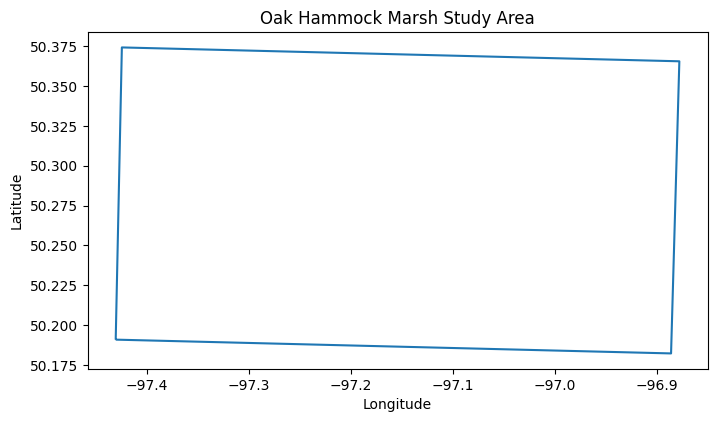

In [4]:
ax = study_area_wgs84.boundary.plot(figsize=(8, 6))

ax.set_title("Oak Hammock Marsh Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Define all Sentinel-2 band paths

In [5]:
import numpy as np

red_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B04_2020-08-08.tif"
)

nir_2020_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2020-08-08"
    / "B08_2020-08-08.tif"
)

nir_2025_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B08_2025-08-02.tif"
)

paths = {
    "2020 B04": red_2020_path,
    "2020 B08": nir_2020_path,
    "2025 B04": red_2025_path,
    "2025 B08": nir_2025_path,
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} — {path}")

2020 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B04_2020-08-08.tif
2020 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2020-08-08/B08_2020-08-08.tif
2025 B04: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B04_2025-08-02.tif
2025 B08: True — /Users/eleazar/Documents/wetland-change-manitoba/data/raw/sentinel2/2025-08-02/B08_2025-08-02.tif


Raster metadata function

In [6]:
def get_raster_metadata(path):
    """Read the spatial and technical properties of a raster."""

    with rasterio.open(path) as src:
        return {
            "crs": src.crs,
            "width": src.width,
            "height": src.height,
            "shape": (src.height, src.width),
            "transform": src.transform,
            "bounds": src.bounds,
            "resolution": src.res,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
        }

Inspect the four rasters

In [7]:
metadata = {
    name: get_raster_metadata(path)
    for name, path in paths.items()
}

for name, info in metadata.items():
    print(f"\n{name}")
    print("-" * len(name))

    for key, value in info.items():
        print(f"{key}: {value}")


2020 B04
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2020 B08
--------
crs: EPSG:32614
width: 2500
height: 1357
shape: (1357, 2500)
transform: | 15.79, 0.00, 612026.01|
| 0.00,-16.44, 5582386.34|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612026.012689, bottom=5560081.552097, right=651500.116106, top=5582386.338637)
resolution: (15.789641366800014, 16.436836064848762)
dtype: uint16
nodata: None

2025 B04
--------
crs: EPSG:32614
width: 2500
height: 1253
shape: (1253, 2500)
transform: | 15.57, 0.00, 612005.80|
| 0.00,-16.26, 5581419.63|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=612005.802059, bottom=5561042.057073, right=650919.85416, top=5581419.634547)
resolution: (15.565620840399992, 16.2

Function to compare raster grids

In [8]:
def compare_raster_grids(path_a, path_b):
    """Compare whether two rasters use the same spatial grid."""

    with rasterio.open(path_a) as raster_a, rasterio.open(path_b) as raster_b:
        return {
            "same_crs": raster_a.crs == raster_b.crs,
            "same_dimensions": (
                raster_a.width == raster_b.width
                and raster_a.height == raster_b.height
            ),
            "same_resolution": np.allclose(
                raster_a.res,
                raster_b.res,
            ),
            "same_transform": np.allclose(
                tuple(raster_a.transform),
                tuple(raster_b.transform),
            ),
            "same_bounds": np.allclose(
                tuple(raster_a.bounds),
                tuple(raster_b.bounds),
            ),
        }

Check alignment within each year

In [9]:
alignment_2020 = compare_raster_grids(
    red_2020_path,
    nir_2020_path,
)

alignment_2025 = compare_raster_grids(
    red_2025_path,
    nir_2025_path,
)

print("2020 B04 and B08 alignment")
for test, result in alignment_2020.items():
    print(f"{test}: {result}")

print("\n2025 B04 and B08 alignment")
for test, result in alignment_2025.items():
    print(f"{test}: {result}")

2020 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True

2025 B04 and B08 alignment
same_crs: True
same_dimensions: True
same_resolution: True
same_transform: True
same_bounds: True


Compare the 2020 and 2025 grids

In [10]:
alignment_between_dates = compare_raster_grids(
    red_2020_path,
    red_2025_path,
)

print("2020 and 2025 grid comparison")

for test, result in alignment_between_dates.items():
    print(f"{test}: {result}")

2020 and 2025 grid comparison
same_crs: True
same_dimensions: False
same_resolution: False
same_transform: False
same_bounds: False
